In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))
import utils.classifiers as classifiers
import utils.normalizer as normalizer

csvfile = os.path.join(os.environ['HOME'], 'git/pyAnomalyDetector/tests/testdata/history.csv')

base_clocks = normalizer.get_base_clocks(1732665600, 1735344000, 86400)
charts = classifiers.load_csv_metrics(csvfile, base_clocks)
clusters, centroids = classifiers.run_kmeans(charts, 0.01, 100)
       

In [3]:
score = classifiers.evaluate_clusters(charts, clusters)
print("score: ", score)

score:  0.32053060946696194


Cluster 0
  Chart ID: 1730055078000000039


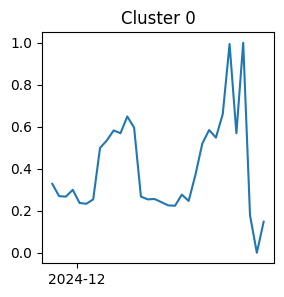

  Chart ID: 1730055078000000040


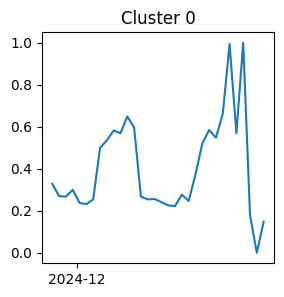

Cluster 1
  Chart ID: 1730063431000000068


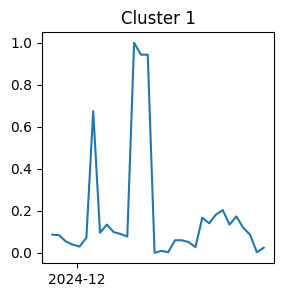

Cluster 2
  Chart ID: 1733275024000000001


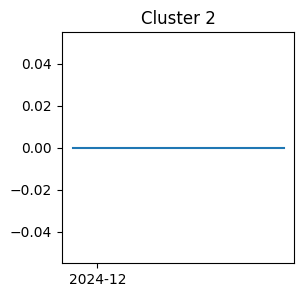

  Chart ID: 1733877482000000001


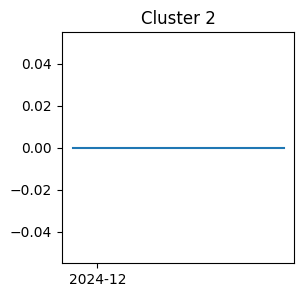

  Chart ID: 1733877510000000002


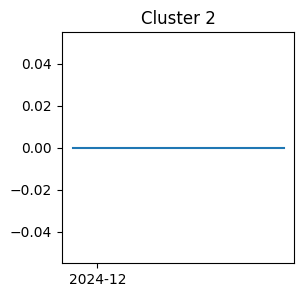

  Chart ID: 1734684530000000005


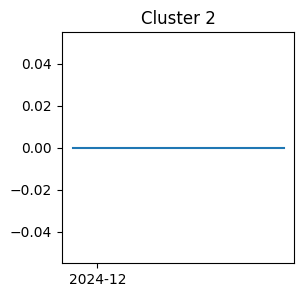

Cluster 3
  Chart ID: 1730447616000000022


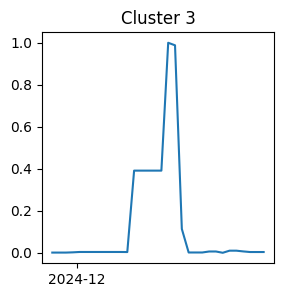

Cluster 4
  Chart ID: 1732711657000000005


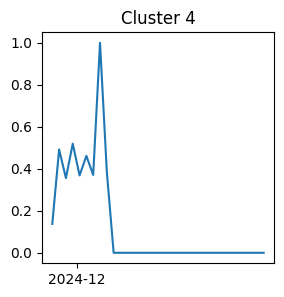

  Chart ID: 1732715096000000012


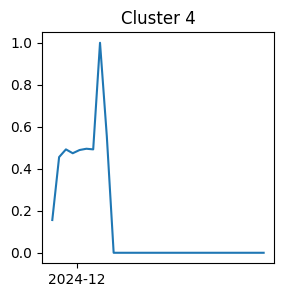

Cluster 5
  Chart ID: 1730243858000000021


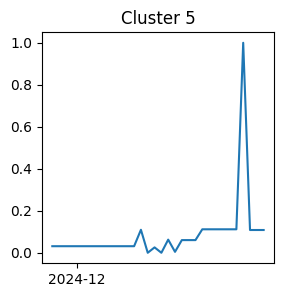

Cluster 6
  Chart ID: 1735170327000000001


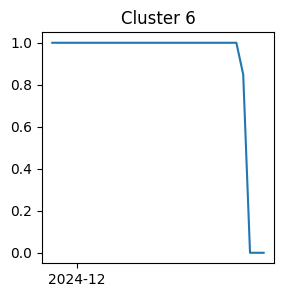

Cluster 7
  Chart ID: 1730053944000000015


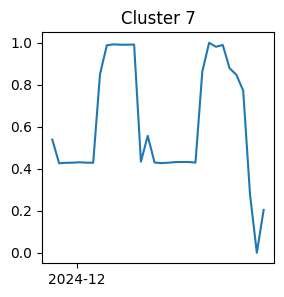

  Chart ID: 1730053944000000016


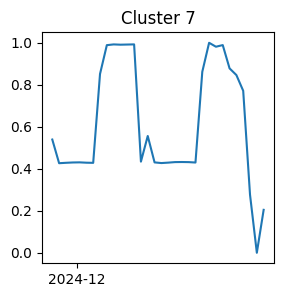

Cluster 8
  Chart ID: 1730098749000000031


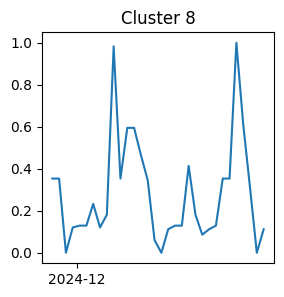

Cluster 9
  Chart ID: 1734094450000000002


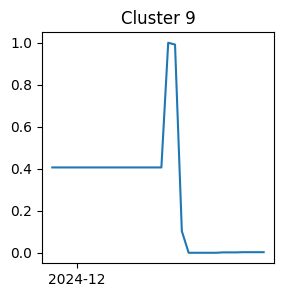

  Chart ID: 1734094450000000003


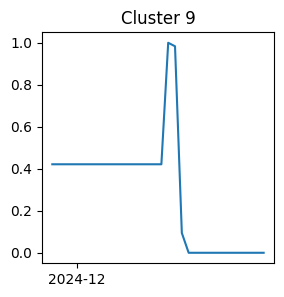

  Chart ID: 1734094453000000004


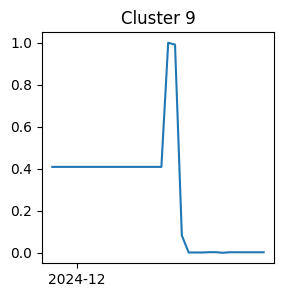

  Chart ID: 1734094453000000005


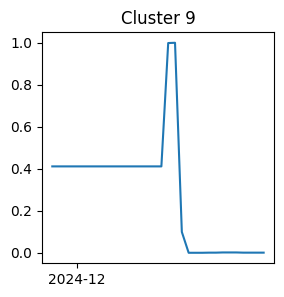

  Chart ID: 1734094453000000006


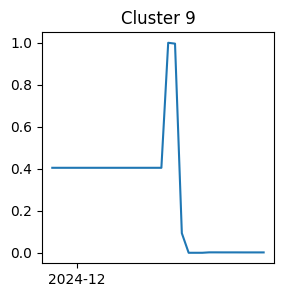

  Chart ID: 1734094459000000007


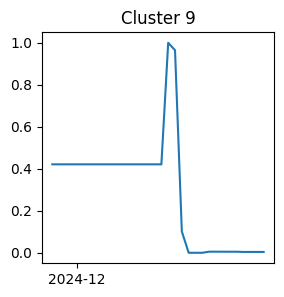

Cluster 10
  Chart ID: 1734960119000000001


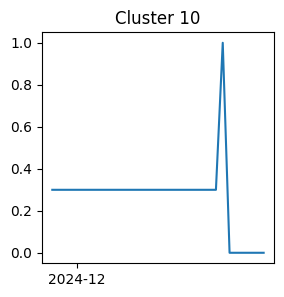

Cluster 11
  Chart ID: 1733877510000000003


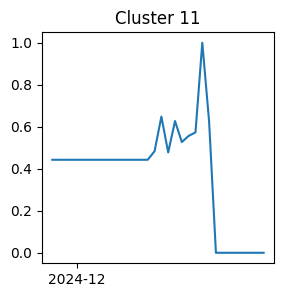

Cluster 12
  Chart ID: 1730055078000000038


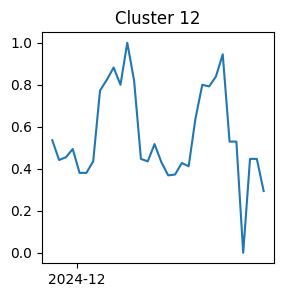

Cluster 13
  Chart ID: 1730072947000000087


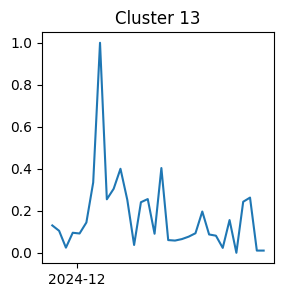

Cluster 14
  Chart ID: 1730102527000000033


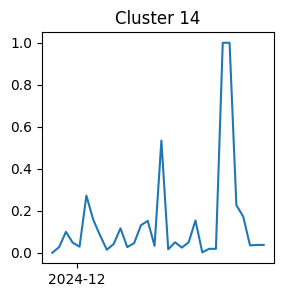

Cluster 15
  Chart ID: 1732711618000000002


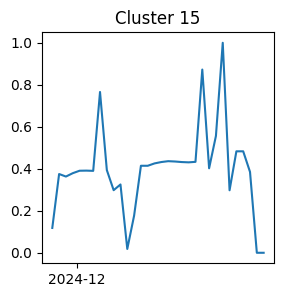

Cluster 16
  Chart ID: 1730304006000000013


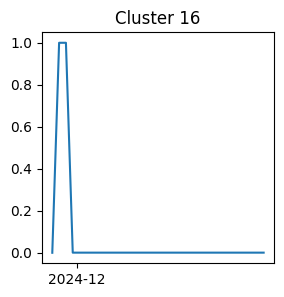

Cluster 17
  Chart ID: 1730074570000000002


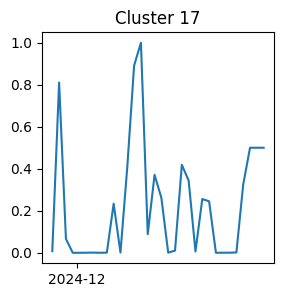

Cluster 18
  Chart ID: 1733656854000000001


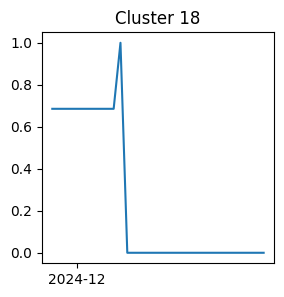

Cluster 19
  Chart ID: 1735130434000000001


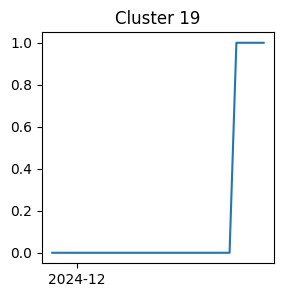

Cluster 20
  Chart ID: 1730053959000000021


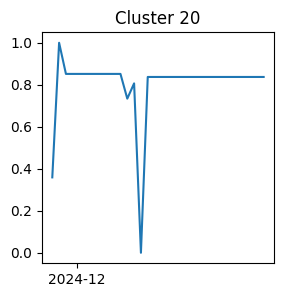

Cluster 21
  Chart ID: 1730053933000000001


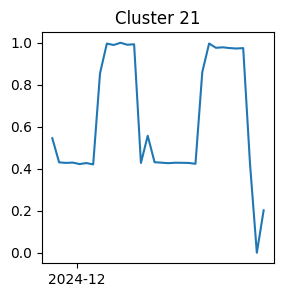

  Chart ID: 1730053933000000002


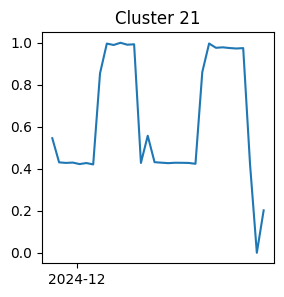

  Chart ID: 1730053933000000003


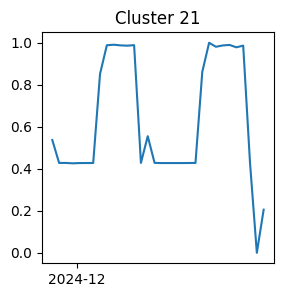

  Chart ID: 1730053933000000004


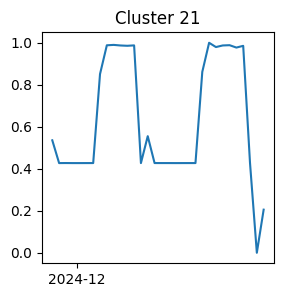

  Chart ID: 1730053935000000007


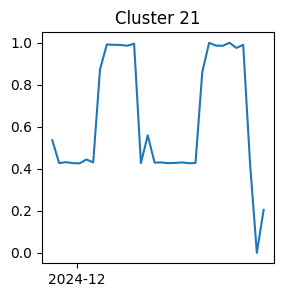

  Chart ID: 1730053937000000008


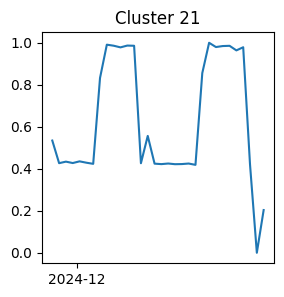

  Chart ID: 1730053940000000012


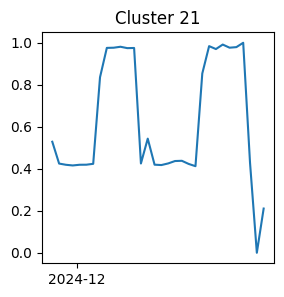

  Chart ID: 1730053943000000013


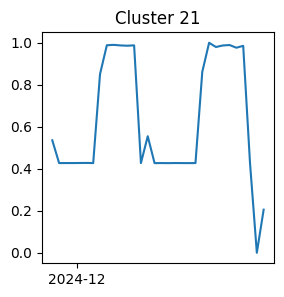

  Chart ID: 1730053947000000017


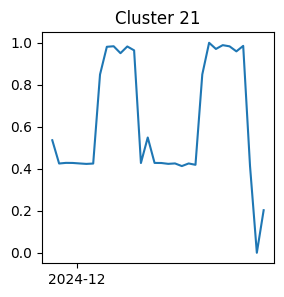

  Chart ID: 1730053949000000018


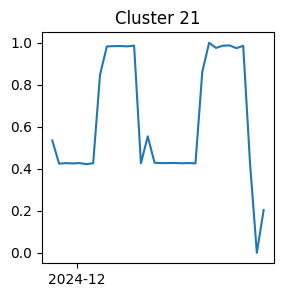

  Chart ID: 1730053971000000024


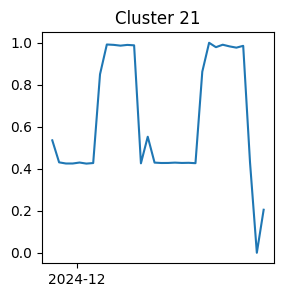

  Chart ID: 1730053998000000025


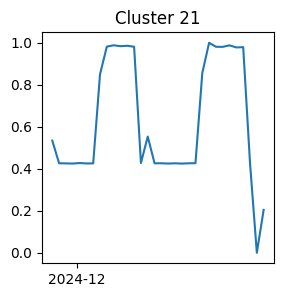

  Chart ID: 1730054084000000027


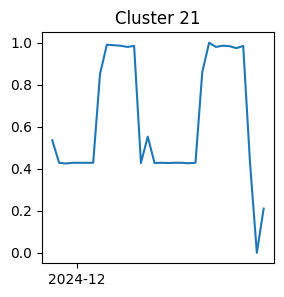

  Chart ID: 1730054241000000031


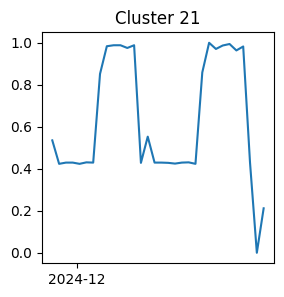

  Chart ID: 1730054402000000032


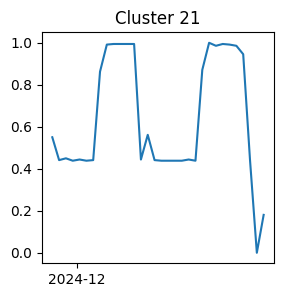

  Chart ID: 1730054497000000034


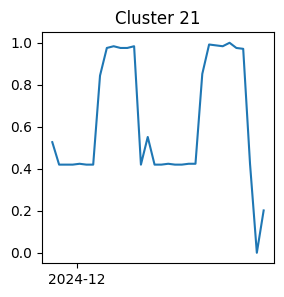

  Chart ID: 1730054577000000035


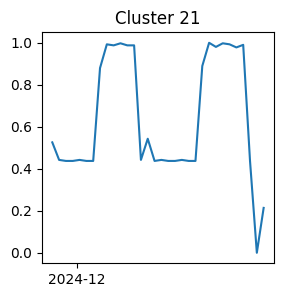

  Chart ID: 1730056120000000049


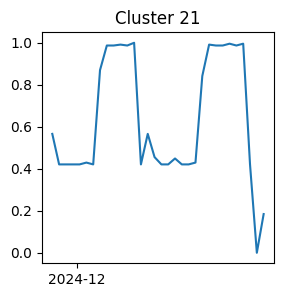

Cluster 22
  Chart ID: 1730072726000000086


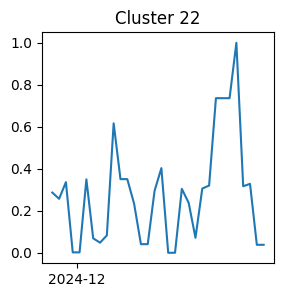

Cluster 23
  Chart ID: 1730081652000000020


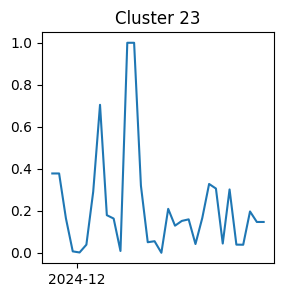

Cluster 24
  Chart ID: 1730056106000000048


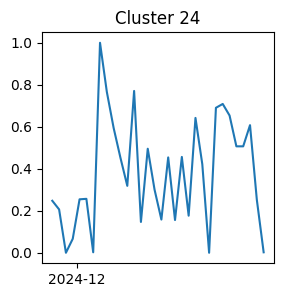

Cluster 25
  Chart ID: 1730076240000000010


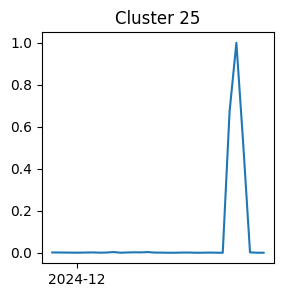

Cluster 26
  Chart ID: 1730053961000000023


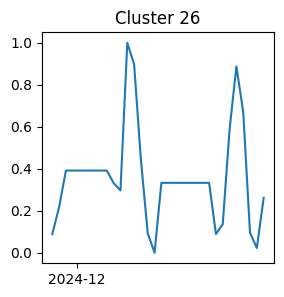

Cluster 27
  Chart ID: 1730072380000000083


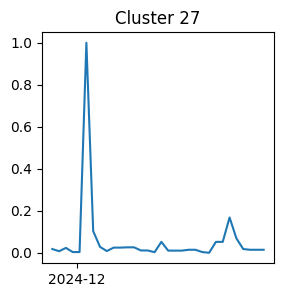

Cluster 28
  Chart ID: 1730078778000000016


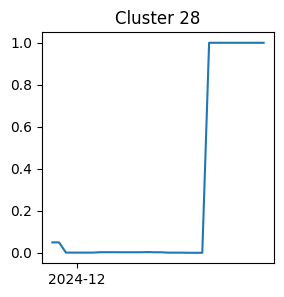

Cluster 29
  Chart ID: 1730078895000000017


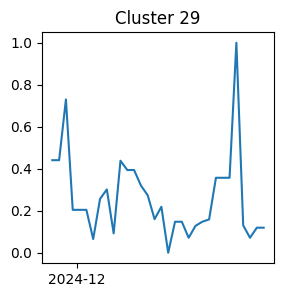

Cluster 30
  Chart ID: 1730072568000000085


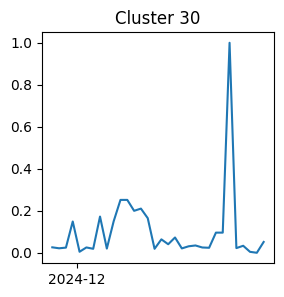

Cluster 31
  Chart ID: 1733922654000000001


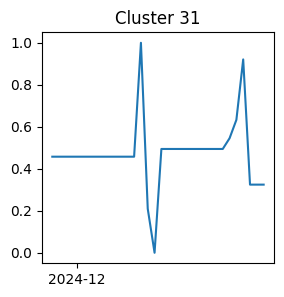

Cluster 32
  Chart ID: 1730053944000000014


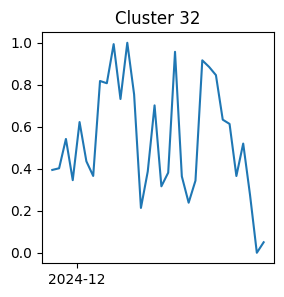

Cluster 33
  Chart ID: 1732711636000000003


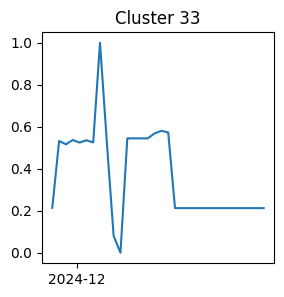

Cluster 34
  Chart ID: 1733749875000000001


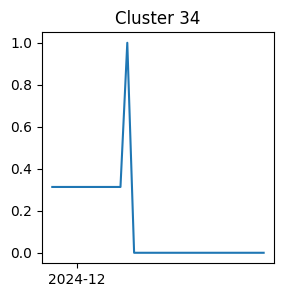

Cluster 35
  Chart ID: 1730077210000000011


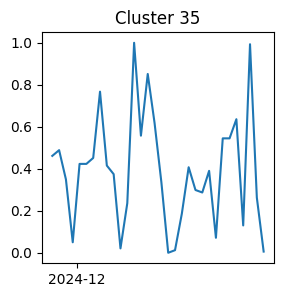

Cluster 36
  Chart ID: 1730055227000000042


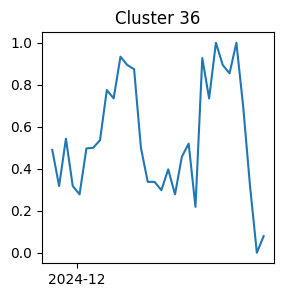

Cluster 37
  Chart ID: 1734094702000000010


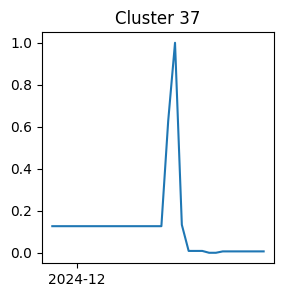

Cluster 38
  Chart ID: 1735041461000000001


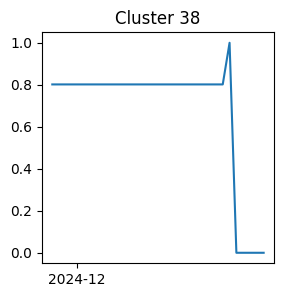

Cluster 39
  Chart ID: 1730075598000000005


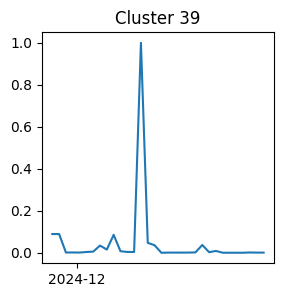

Cluster 40
  Chart ID: 1730054163000000030


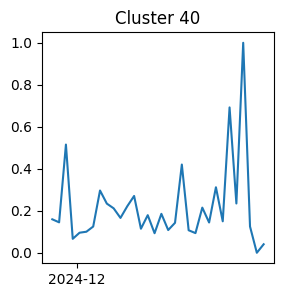

Cluster 41
  Chart ID: 1730074901000000004


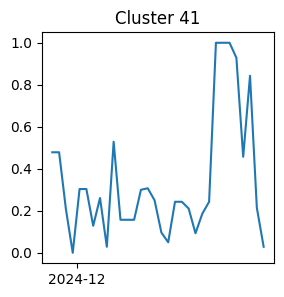

Cluster 42
  Chart ID: 1730072567000000084


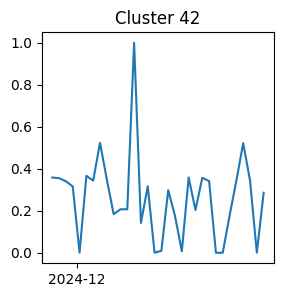

Cluster 43
  Chart ID: 1730062961000000065


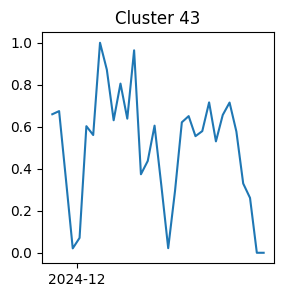

Cluster 44
  Chart ID: 1730053940000000011


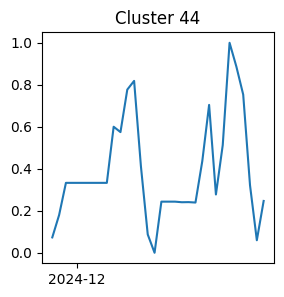

Cluster 45
  Chart ID: 1730081216000000018


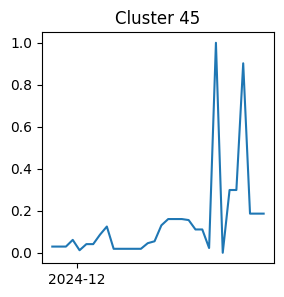

Cluster 46
  Chart ID: 1732711617000000001


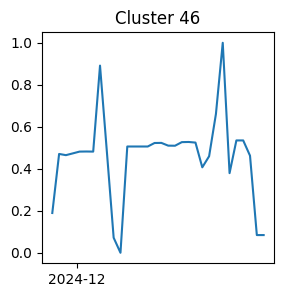

Cluster 47
  Chart ID: 1733880271000000013


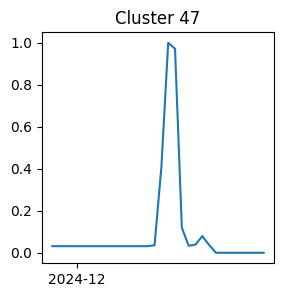

  Chart ID: 1733880271000000014


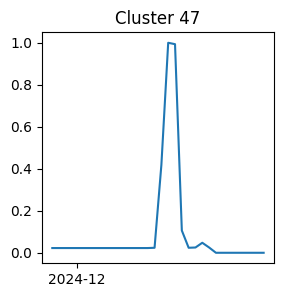

Cluster 48
  Chart ID: 1730054404000000033


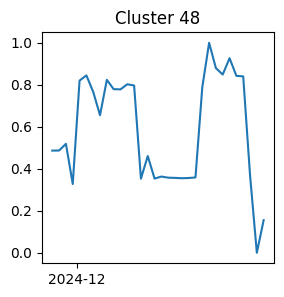

Cluster 49
  Chart ID: 1730077399000000013


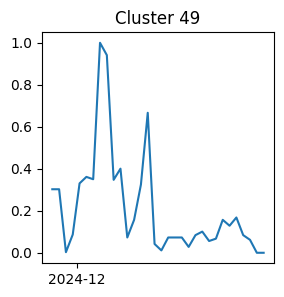

Cluster 50
  Chart ID: 1730053939000000009


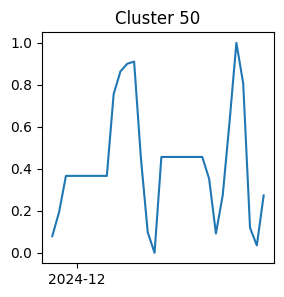

Cluster 51
  Chart ID: 1734858737000000001


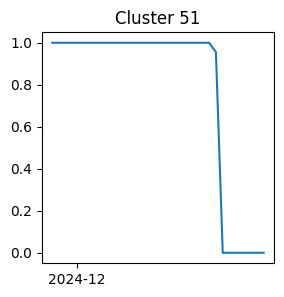

Cluster 52
  Chart ID: 1730084401000000022


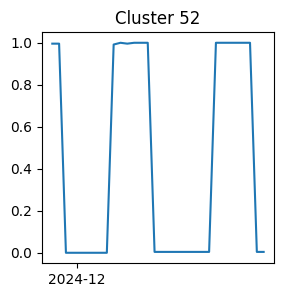

Cluster 53
  Chart ID: 1733791172000000001


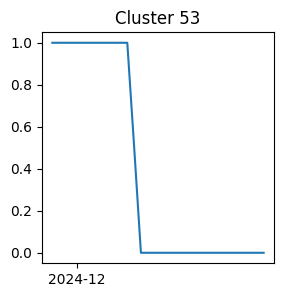

Cluster 54
  Chart ID: 1732751391000000042


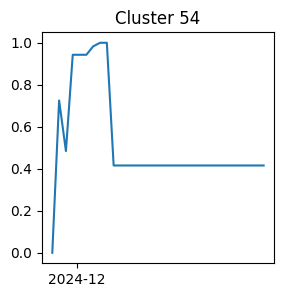

Cluster 55
  Chart ID: 1730055324000000043


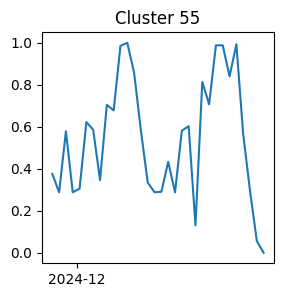

Cluster 56
  Chart ID: 1733567134000000001


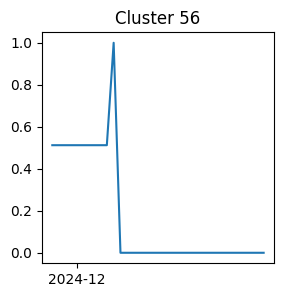

Cluster 57
  Chart ID: 1730053959000000020


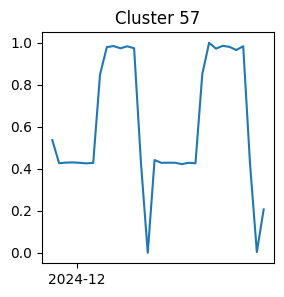

  Chart ID: 1730053960000000022


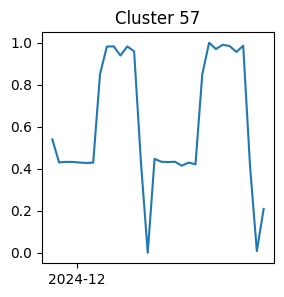

Cluster 58
  Chart ID: 1732711638000000004


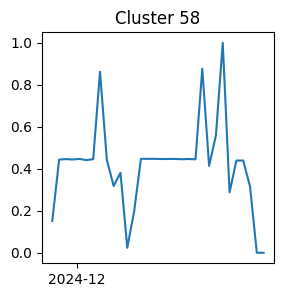

Cluster 59
  Chart ID: 1730053940000000010


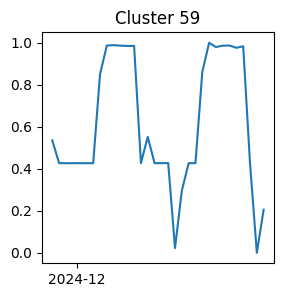

Cluster 60
  Chart ID: 1733877940000000007


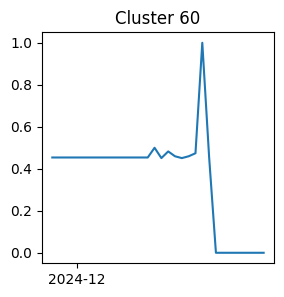

Cluster 61
  Chart ID: 1730053949000000019


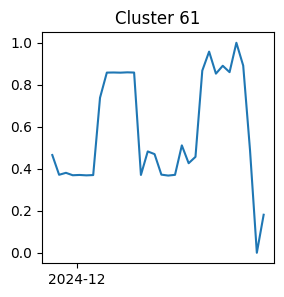

Cluster 62
  Chart ID: 1730053934000000005


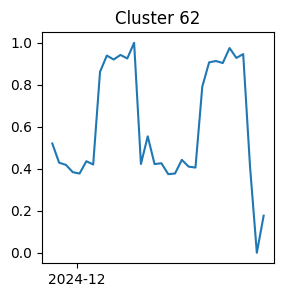

  Chart ID: 1730054105000000028


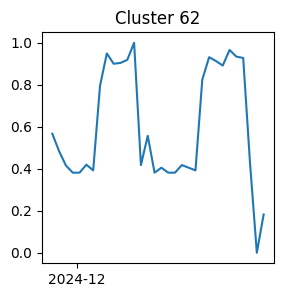

  Chart ID: 1730054135000000029


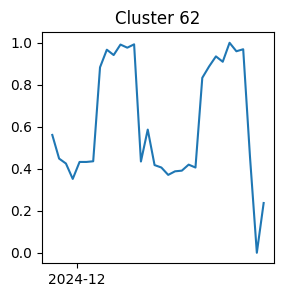

Cluster 63
  Chart ID: 1734099383000000011


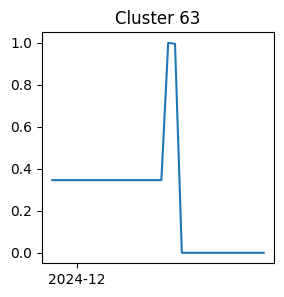

Cluster 64
  Chart ID: 1730447616000000012


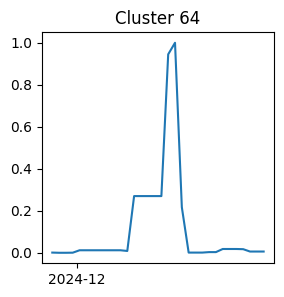

Cluster 65
  Chart ID: 1735264878000000001


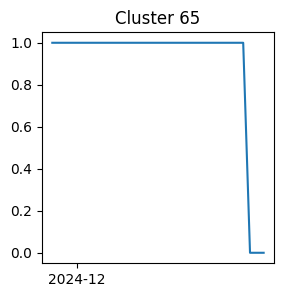

Cluster 66
  Chart ID: 1730053934000000006


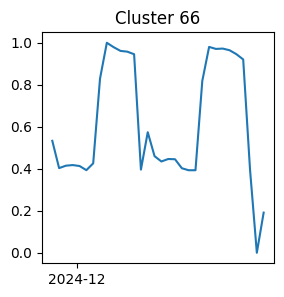

  Chart ID: 1730054080000000026


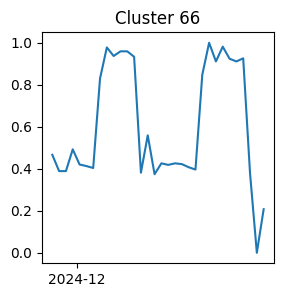

In [2]:
cluster_members = {}
for cluster_id in centroids.keys():
    for chart_id in clusters:
        if clusters[chart_id] == cluster_id:
            if cluster_id not in cluster_members:
                cluster_members[cluster_id] = []
            cluster_members[cluster_id].append(chart_id)

# plot the ordered charts
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# convert base_clocks(epoch) to datetime objects
base_times = [datetime.fromtimestamp(x) for x in base_clocks]

def plot_chart(chart, cluster_id):
    fig, ax = plt.subplots()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.plot(base_times, list(chart))
    ax.set_title(f'Cluster {cluster_id}')
    # set size of the plot
    fig.set_size_inches(3, 3)
    plt.show()

for cluster_id in cluster_members.keys():
    print(f'Cluster {cluster_id}')
    for chart_id in cluster_members[cluster_id]:
        chart = charts[chart_id]
        print(f'  Chart ID: {chart_id}')
        plot_chart(chart, cluster_id)


